# Voice Recognition & Voiceprint Verification Model

**Formative 2 – Sound Data Collection and Processing + Voiceprint Verification**

This notebook:
- Uses local **data/audio/samples/** for audio data
- Loads audio files and **extracts labels from the first part of the filename** (e.g. `Yunis-REC.wav` → label `Yunis`)
- Displays waveforms and spectrograms
- Applies augmentations (pitch shift, time stretch, background noise)
- Extracts features (MFCCs, spectral roll-off, energy) and saves to `audio_features.csv`
- Trains a **Voiceprint Verification Model** and evaluates with Accuracy, F1-Score, and Loss

## 1. Installing Dependencies

In [1]:
!pip install librosa
!pip install soundfile
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Imports and configuration

In [2]:
import librosa
import soundfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, log_loss
import joblib


# Ensure project root for paths
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
PROJECT_ROOT = Path.cwd()
AUDIO_ROOT = str(PROJECT_ROOT / "data" / "audio" / "samples")

## 3. Load audio files and extract labels from filenames

Labels are taken from the **first part of the filename** before the first hyphen.  
Example: `Yunis-REC.wav` → label **Yunis**

In [3]:
AUDIO_EXTENSIONS = {".wav", ".mp3", ".flac", ".ogg", ".m4a"}

def get_label_from_filename(filename):
    """Extract label from filename: part before the first hyphen. E.g. 'Yunis-REC.wav' -> 'Yunis'"""
    stem = Path(filename).stem
    if "-" in stem:
        return stem.split("-")[0].strip()
    return stem

def load_audio_dataset(root_dir):
    """Scan root_dir for audio files and return list of (filepath, label)."""
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"Audio folder not found: {root_dir}")
    samples = []
    for f in root.rglob("*"):
        if f.suffix.lower() in AUDIO_EXTENSIONS:
            label = get_label_from_filename(f.name)
            samples.append((str(f.resolve()), label))
    return samples

# Load all audio paths and labels
audio_samples = load_audio_dataset(AUDIO_ROOT)
print(f"Found {len(audio_samples)} audio files")
if audio_samples:
    for path, label in audio_samples:
        print(f"  {Path(path).name} -> label: '{label}'")

Found 8 audio files
  Preye-REC.m4a -> label: 'Preye'
  Bonaparte-REC.m4a -> label: 'Bonaparte'
  Josue-REC.m4a -> label: 'Josue'
  Josue-REC(1).m4a -> label: 'Josue'
  Preye-REC(1).m4a -> label: 'Preye'
  Yunis-REC(1).m4a -> label: 'Yunis'
  Bonaparte-REC(1).m4a -> label: 'Bonaparte'
  Yunis-REC.m4a -> label: 'Yunis'


## 4. Load and display waveforms and spectrograms

We load each audio file and plot waveform and spectrogram for inspection.

/var/folders/rg/3kl2bdtd295ds1z2np16ry0m0000gn/T/ipykernel_5049/648746621.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_actual = librosa.load(path, sr=sr, mono=True)
/Users/avellin/Desktop/Campus/ml-pipeline-formative-2/VoiceModel/myenv/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


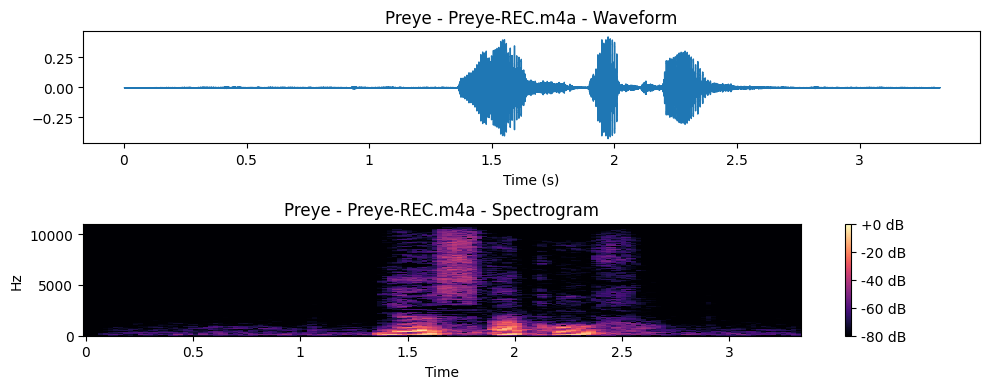

/var/folders/rg/3kl2bdtd295ds1z2np16ry0m0000gn/T/ipykernel_5049/648746621.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_actual = librosa.load(path, sr=sr, mono=True)
/Users/avellin/Desktop/Campus/ml-pipeline-formative-2/VoiceModel/myenv/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


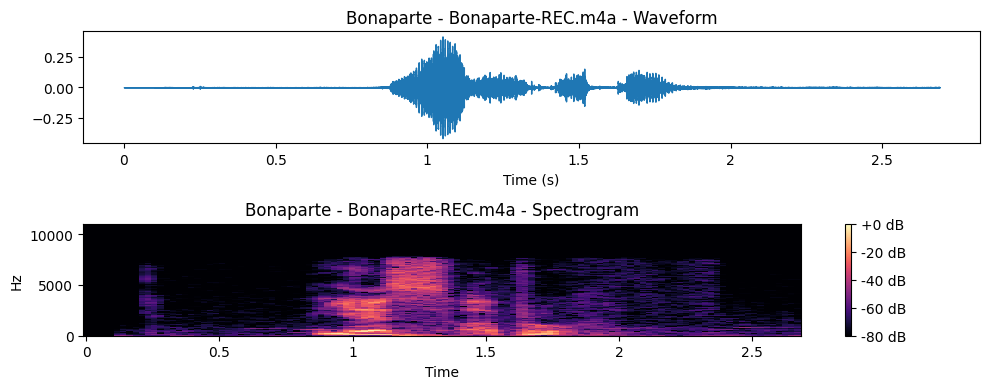

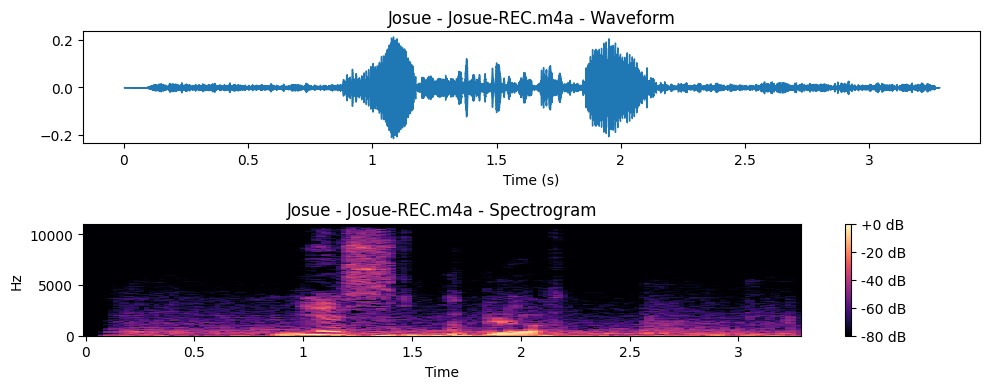

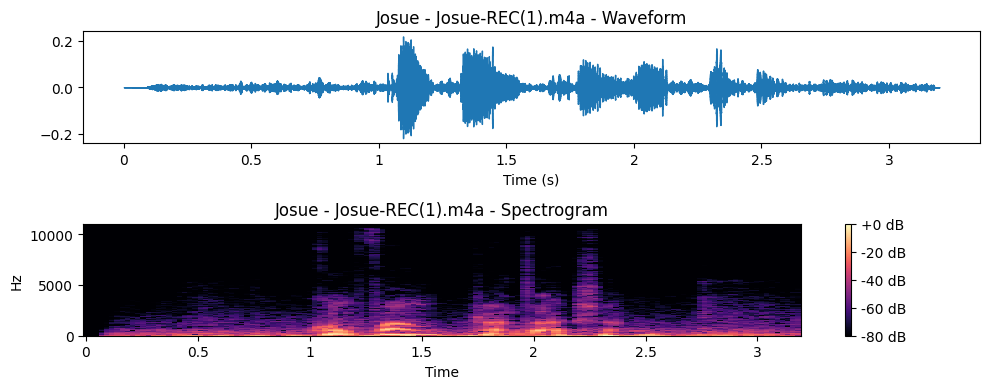

In [4]:
def load_audio_mono(path, sr=22050):
    """Load audio as mono at given sample rate."""
    y, sr_actual = librosa.load(path, sr=sr, mono=True)
    return y, sr_actual

def plot_waveform_and_spectrogram(y, sr, title="Audio", ax_wav=None, ax_spec=None):
    if ax_wav is None:
        fig, (ax_wav, ax_spec) = plt.subplots(2, 1, figsize=(10, 4))
    librosa.display.waveshow(y, sr=sr, ax=ax_wav)
    ax_wav.set_title(f"{title} - Waveform")
    ax_wav.set_xlabel("Time (s)")
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz", ax=ax_spec)
    ax_spec.set_title(f"{title} - Spectrogram")
    plt.colorbar(img, ax=ax_spec, format="%+2.0f dB")
    plt.tight_layout()


n_show = min(4, len(audio_samples))
for i in range(n_show):
    path, label = audio_samples[i]
    y, sr = load_audio_mono(path)
    fig, (ax_wav, ax_spec) = plt.subplots(2, 1, figsize=(10, 4))
    plot_waveform_and_spectrogram(y, sr, f"{label} - {Path(path).name}", ax_wav, ax_spec)
    plt.show()

## 5. Audio augmentations

We apply **at least two augmentations per sample**: pitch shift, time stretch, and background noise.  
Augmented signals are used to expand the dataset and improve model robustness.

In [5]:
def augment_pitch_shift(y, sr, n_steps=2):
    """Pitch shift by n_steps semitones."""
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def augment_time_stretch(y, rate=1.2):
    """Time stretch by rate (e.g. 1.2 = 20% slower)."""
    return librosa.effects.time_stretch(y, rate=rate)

def augment_add_noise(y, noise_factor=0.005):
    """Add Gaussian background noise."""
    noise = np.random.randn(len(y)).astype(np.float32) * noise_factor
    return y + noise


SR = 22050
all_audio_for_features = []

for path, label in audio_samples:
    y, sr = load_audio_mono(path, sr=SR)
    all_audio_for_features.append((y.copy(), sr, label, "original"))

    # Augmentation 1: pitch shift
    y_pitch = augment_pitch_shift(y, sr, n_steps=1.5)
    all_audio_for_features.append((y_pitch, sr, label, "pitch_shift"))

    # Augmentation 2: time stretch
    y_stretch = augment_time_stretch(y, rate=1.15)
    all_audio_for_features.append((y_stretch, sr, label, "time_stretch"))

    # Augmentation 3: background noise
    y_noise = augment_add_noise(y, noise_factor=0.003)
    all_audio_for_features.append((y_noise, sr, label, "noise"))

print(f"Total clips for feature extraction: {len(all_audio_for_features)} (original + 3 augmentations per file)")

/var/folders/rg/3kl2bdtd295ds1z2np16ry0m0000gn/T/ipykernel_5049/648746621.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_actual = librosa.load(path, sr=sr, mono=True)
/var/folders/rg/3kl2bdtd295ds1z2np16ry0m0000gn/T/ipykernel_5049/648746621.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_actual = librosa.load(path, sr=sr, mono=True)
/Users/avellin/Desktop/Campus/ml-pipeline-formative-2/VoiceModel/myenv/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Total clips for feature extraction: 32 (original + 3 augmentations per file)


## 6. Feature extraction (MFCCs, spectral roll-off, energy)

Extract and save features to **audio_features.csv** for use in the voiceprint model and elsewhere in the pipeline.

In [11]:
def extract_audio_features(y, sr, n_mfcc=13):
    """Extract MFCCs, spectral roll-off, and energy (RMS). Returns a flat feature vector."""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rolloff_mean = np.mean(rolloff)
    rolloff_std = np.std(rolloff)

    rms = librosa.feature.rms(y=y)[0]
    energy_mean = np.mean(rms)
    energy_std = np.std(rms)

    return np.concatenate([mfcc_mean, mfcc_std, [rolloff_mean, rolloff_std], [energy_mean, energy_std]])


feature_rows = []
for y, sr, label, source_name in all_audio_for_features:
    feat = extract_audio_features(y, sr)
    row = {"label": label, "source": source_name}
    n_mfcc = 13
    for i in range(n_mfcc):
        row[f"mfcc_mean_{i}"] = feat[i]
    for i in range(n_mfcc):
        row[f"mfcc_std_{i}"] = feat[n_mfcc + i]
    row["spectral_rolloff_mean"] = feat[2 * n_mfcc]
    row["spectral_rolloff_std"] = feat[2 * n_mfcc + 1]
    row["energy_mean"] = feat[2 * n_mfcc + 2]
    row["energy_std"] = feat[2 * n_mfcc + 3]
    feature_rows.append(row)

df_audio = pd.DataFrame(feature_rows)
print("Extracted features shape:", df_audio.shape)
print(df_audio.head())

Extracted features shape: (32, 32)
       label        source  mfcc_mean_0  mfcc_mean_1  mfcc_mean_2  \
0      Preye      original  -482.510529    94.569000    51.099728   
1      Preye   pitch_shift  -517.774963   100.557396    49.803185   
2      Preye  time_stretch  -515.625366    96.735329    52.060188   
3      Preye         noise  -325.958923    35.419067    23.979612   
4  Bonaparte      original  -456.107056    87.028366     6.822984   

   mfcc_mean_3  mfcc_mean_4  mfcc_mean_5  mfcc_mean_6  mfcc_mean_7  ...  \
0    17.170298    -2.652241     6.247245     4.586445     2.172824  ...   
1     9.721700    -4.738628     6.054902     3.449969     0.222056  ...   
2    16.204845    -3.771115     6.355096     4.401138     1.128205  ...   
3     8.570280     1.111915     2.631340     1.140139     1.713344  ...   
4    38.934639    -7.270165     1.878408    -4.659694     9.108379  ...   

   mfcc_std_7  mfcc_std_8  mfcc_std_9  mfcc_std_10  mfcc_std_11  mfcc_std_12  \
0   12.825520    9.

In [7]:
# Save to data/processed/audio_features.csv
AUDIO_FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "audio_features.csv"
df_audio.to_csv(AUDIO_FEATURES_PATH, index=False)
print(f"Saved audio_features.csv to {AUDIO_FEATURES_PATH}")

Saved audio_features.csv to /Users/avellin/Desktop/Campus/ml-pipeline-formative-2/VoiceModel/audio_features.csv


## 7. Voiceprint verification model

Train a classifier (Random Forest) to verify voice identity from the extracted features.  
We evaluate with **Accuracy**, **F1-Score**, and **Loss** (log loss for probabilistic evaluation).

,Metric,Value
0,Accuracy,0.8750
1,F1-Score (weighted),0.8667
2,Log Loss,0.4618


,precision,recall,f1-score,support
Bonaparte,1.0000,0.500,0.6667,2.000
Josue,1.0000,1.000,1.0000,2.000
Preye,0.6667,1.000,0.8000,2.000
Yunis,1.0000,1.000,1.0000,2.000
accuracy,0.8750,0.875,0.8750,0.875
macro avg,0.9167,0.875,0.8667,8.000
weighted avg,0.9167,0.875,0.8667,8.000


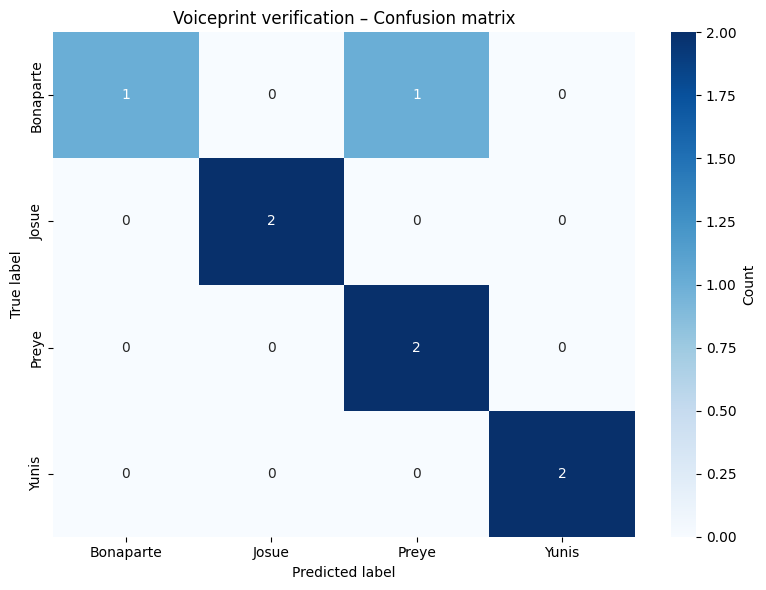

In [8]:
# Prepare X and y
feature_cols = [c for c in df_audio.columns if c not in ("label", "source")]
X = df_audio[feature_cols]
y = df_audio["label"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train Random Forest (voiceprint verification model)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
loss = log_loss(y_test, y_proba)

# Metrics table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1-Score (weighted)", "Log Loss"],
    "Value": [round(accuracy, 4), round(f1, 4), round(loss, 4)]
})
display(metrics_df)

# Classification report as DataFrame
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.round(4)
display(report_df)

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Voiceprint verification – Confusion matrix")
plt.tight_layout()
plt.show()

In [9]:
# Save scaler, label encoder, and model for use in CLI
MODEL_DIR = str(PROJECT_ROOT / "models")
joblib.dump(scaler, os.path.join(MODEL_DIR, "voice_scaler.joblib"))
joblib.dump(le, os.path.join(MODEL_DIR, "voice_label_encoder.joblib"))
joblib.dump(model, os.path.join(MODEL_DIR, "voiceprint_model.joblib"))
print(f"Saved voiceprint model, scaler, and label encoder to {MODEL_DIR}")

Saved voiceprint model, scaler, and label encoder to /Users/avellin/Desktop/Campus/ml-pipeline-formative-2/VoiceModel


## Summary

- **Audio data**: Loaded from local **data/audio/samples/**.
- **Labels**: Taken from the first part of each filename before `-` (e.g. `Yunis-REC.wav` → `Yunis`).
- **Visualizations**: Waveforms and spectrograms are shown for sample files.
- **Augmentations**: Pitch shift, time stretch, and background noise applied per sample.
- **Features**: MFCCs, spectral roll-off, and energy saved in **data/processed/audio_features.csv**.
- **Model**: Voiceprint verification via Random Forest; evaluated with Accuracy, F1-Score, and Log Loss.
- **Artifacts**: Model, scaler, and label encoder are saved in **models/** for the CLI/system simulation.